# 10 - Regression: predicting Stockfish's evaluation

New task: instead of predicting who wins (`white_win`, classification), predict `eval_cp` — the continuous, unified Stockfish evaluation from `unify_score()` back in `02_labels_and_split.ipynb`. This reuses the same 39 board features, but now the question is "how well do hand-engineered features approximate what Stockfish's search-based engine already computed," not "who wins."

Elo/player columns are excluded here on purpose — this is strictly a board-understanding task, the same framing we called the "board-only" model in the classification Elo experiment.

Plan:
1. Inspect the `eval_cp` distribution — it's heavy-tailed by construction (mate positions sit at ±10000, far beyond the ±2000 cap on ordinary centipawn scores), which matters for regression since squared-error loss is sensitive to outliers
2. Baseline: Linear Regression, evaluated with MAE, RMSE, R²
3. Compare against Random Forest, HistGradientBoostingRegressor, XGBRegressor
4. Test whether mate positions are actually hurting the fit, by comparing all-positions vs. mate-excluded

In [1]:
import sys
sys.path.append('..')

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

from src.features import extract_features_v3

train_df = pd.read_csv('../data/processed/train_features_v3.csv', low_memory=False)
test_df = pd.read_csv('../data/processed/test_features_v3.csv', low_memory=False)

feature_cols = list(extract_features_v3(train_df['fen'].iloc[0]).keys())
X_train, y_train = train_df[feature_cols], train_df['eval_cp']
X_test, y_test = test_df[feature_cols], test_df['eval_cp']

print(f'{len(feature_cols)} features')
X_train.shape, X_test.shape

39 features


((822936, 39), (208378, 39))

## Inspect `eval_cp`'s distribution

count    822936.000000
mean        134.000599
std        3086.942748
min       -9999.000000
25%        -167.000000
50%          10.000000
75%         272.000000
max        9999.000000
Name: eval_cp, dtype: float64

mate positions (|eval_cp| > 2000): 77,155 / 822,936 (9.4%)


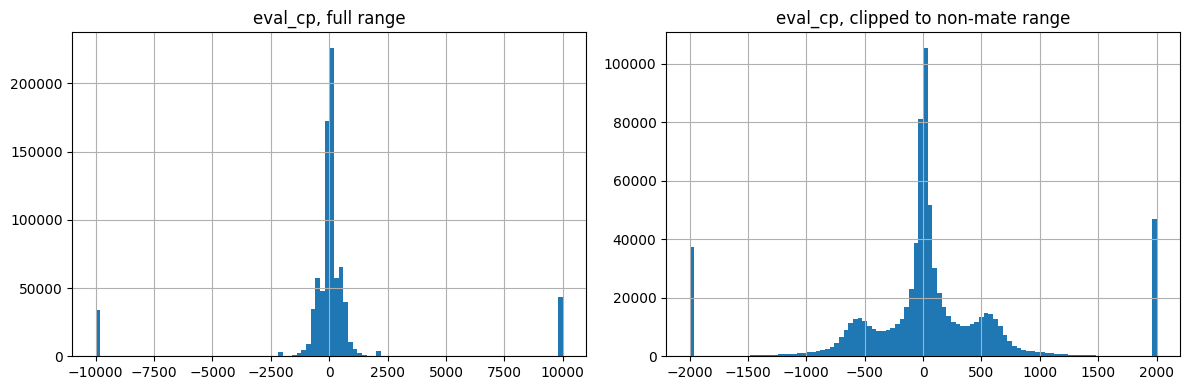

In [2]:
print(y_train.describe())
print(f"\nmate positions (|eval_cp| > 2000): {(y_train.abs() > 2000).sum():,} / {len(y_train):,} ({(y_train.abs() > 2000).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train.hist(bins=100, ax=axes[0])
axes[0].set_title('eval_cp, full range')
y_train.clip(-2000, 2000).hist(bins=100, ax=axes[1])
axes[1].set_title('eval_cp, clipped to non-mate range')
plt.tight_layout()

## Baseline: Linear Regression
Regression's evaluation metrics are different from classification's — no precision/recall here:
- **MAE** (mean absolute error): average size of the miss, in centipawns, easy to interpret directly
- **RMSE** (root mean squared error): penalizes large misses more heavily than small ones (squares the errors before averaging) — sensitive to the mate-position outliers
- **R²**: fraction of variance in `eval_cp` explained by the model (1.0 = perfect, 0.0 = no better than predicting the mean)

In [3]:
def evaluate_regressor(name, model, X_tr, X_te, y_tr, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    fit_seconds = time.time() - start

    preds = model.predict(X_te)
    metrics = {
        'model': name,
        'mae': mean_absolute_error(y_te, preds),
        'rmse': np.sqrt(mean_squared_error(y_te, preds)),
        'r2': r2_score(y_te, preds),
        'fit_seconds': fit_seconds,
    }
    print(f"{name}: MAE={metrics['mae']:.1f}  RMSE={metrics['rmse']:.1f}  R2={metrics['r2']:.4f}  (fit in {fit_seconds:.1f}s)")
    return metrics, model


results = []

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

metrics, _ = evaluate_regressor('Linear Regression', LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)
results.append(metrics)

Linear Regression: MAE=1371.2  RMSE=3105.1  R2=0.0460  (fit in 1.9s)


## Tree-based regressors
Same lineup as the classifier comparison — no scaling needed for any of these.

In [4]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
metrics, rf = evaluate_regressor('Random Forest', rf, X_train, X_test, y_train, y_test)
results.append(metrics)

hgb = HistGradientBoostingRegressor(max_iter=300, random_state=42)
metrics, hgb = evaluate_regressor('Gradient Boosting (HistGB)', hgb, X_train, X_test, y_train, y_test)
results.append(metrics)

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42)
metrics, xgb_model = evaluate_regressor('XGBoost', xgb_model, X_train, X_test, y_train, y_test)
results.append(metrics)

pd.DataFrame(results).set_index('model').round(2)

Random Forest: MAE=700.9  RMSE=1768.9  R2=0.6904  (fit in 82.3s)


Gradient Boosting (HistGB): MAE=738.5  RMSE=1737.3  R2=0.7014  (fit in 7.0s)


XGBoost: MAE=749.9  RMSE=1744.4  R2=0.6989  (fit in 2.8s)


,mae,rmse,r2,fit_seconds
model,,,,
Linear Regression,1371.16,3105.13,0.05,1.92
Random Forest,700.91,1768.87,0.69,82.28
Gradient Boosting (HistGB),738.52,1737.25,0.70,7.01
XGBoost,749.89,1744.38,0.70,2.85


## Are mate positions actually hurting the fit?
Test the hypothesis directly, same pattern as the Elo experiment: fit and evaluate on the *same* mate-excluded rows both times, isolating whether removing them changes anything, rather than assuming.

In [5]:
train_no_mate = train_df['mate'].isna()
test_no_mate = test_df['mate'].isna()

X_train_nm, y_train_nm = train_df.loc[train_no_mate, feature_cols], train_df.loc[train_no_mate, 'eval_cp']
X_test_nm, y_test_nm = test_df.loc[test_no_mate, feature_cols], test_df.loc[test_no_mate, 'eval_cp']

print(f'train: {train_no_mate.sum():,} / {len(train_df):,} non-mate rows')
print(f'test:  {test_no_mate.sum():,} / {len(test_df):,} non-mate rows')

mate_results = []

# trained on ALL rows (mate included), evaluated only on the non-mate test subset
metrics, _ = evaluate_regressor(
    'HistGB, trained with mate positions (eval on non-mate only)',
    HistGradientBoostingRegressor(max_iter=300, random_state=42),
    X_train, X_test_nm, y_train, y_test_nm,
)
mate_results.append(metrics)

# trained AND evaluated on non-mate rows only
metrics, _ = evaluate_regressor(
    'HistGB, trained without mate positions (eval on non-mate only)',
    HistGradientBoostingRegressor(max_iter=300, random_state=42),
    X_train_nm, X_test_nm, y_train_nm, y_test_nm,
)
mate_results.append(metrics)

pd.DataFrame(mate_results).set_index('model')[['mae', 'rmse', 'r2']].round(2)

train: 742,042 / 822,936 non-mate rows
test:  186,691 / 208,378 non-mate rows


HistGB, trained with mate positions (eval on non-mate only): MAE=442.7  RMSE=963.8  R2=-3.3507  (fit in 6.9s)


HistGB, trained without mate positions (eval on non-mate only): MAE=148.9  RMSE=245.3  R2=0.7182  (fit in 6.7s)


,mae,rmse,r2
model,,,
"HistGB, trained with mate positions (eval on non-mate only)",442.72,963.77,-3.35
"HistGB, trained without mate positions (eval on non-mate only)",148.94,245.29,0.72


## Feature importances for the regression task
Compare against the classification importances — does what predicts *who wins* also predict *how good the position is right now*?

In [6]:
pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False).head(15)

,feature,importance
10,material_diff,0.352698
11,side_to_move_white,0.201849
16,mobility_white,0.104102
17,mobility_black,0.096086
22,in_check,0.051250
18,mobility_diff,0.043650
23,fullmove_number,0.041250
38,material_diff_x_endgame,0.016418
5,black_pawns,0.015989
0,white_pawns,0.012120
